# Лабораторный практикум по курсу «Разговорный ИИ и большие языковые модели», Университет ИТМО, 2026
**Лабораторная работа №1.**

**Цель работы:** Обучить модель векторизации на задаче мультиклассовой классификации текстов

**Задачи:**
1. Выбрать датасет для задачи классификации текстов (https://huggingface.co/datasets)
2. Выбрать модель векторизации (https://huggingface.co/models)
3. Обучить классификатор с mean_pooling.
4. Посчитать метрики: F1-Score, Precision, Recall. 
5. Обучить классификатор с cls_pooling.
6. Посчитать метрики: F1-Score, Precision, Recall.
7. Сравнить метрики полученные при использовании разных стратегий пулинга

In [68]:
import os
import gc
import time
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
from tqdm.auto import tqdm
from datasets import Dataset
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, TrainingArguments, Trainer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score, accuracy_score


In [2]:
torch.cuda.is_available()

True

In [3]:
print(torch.cuda.get_device_name(0))

NVIDIA GeForce GTX 1080 Ti


### 1. Выбор датасета для задачи классификации текстов

**Датасет:** В качестве корпуса данных для задачи классификации текстов взят ag_news (https://huggingface.co/datasets/fancyzhx/ag_news), содержащий новостные статьи на английском языке.

- Подходит для мультиклассовой классификации;
- Классы сбалансированы (по 30 000 в train);

**Классы:**

| Метка | Класс    |
|-------|----------|
| 0     | World    |
| 1     | Sports   |
| 2     | Business |
| 3     | Sci/Tech |

**Разбиение:**

| Split | Примеров |
|-------|----------|
| train | 120 000  |
| test  | 7 600    |

### 2. Выбор модели векторизации 

**Модель:** distilbert-base-uncased https://huggingface.co/distilbert-base-uncased - дистиллированная версия BERT: encoder-only Transformer из 6 блоков.  
**BERT** - это стек encoder-блоков, обучаемый через MLM;  
**DistilBERT** повторяет архитектуру BERT, но вдвое компактнее, при этом сохраняет качество.

- Является encoder-only моделью семейства BERT;
- Быстрее bert-base при потере качества на 1–2%;
- Возвращает и cls-эмбеддинг, и токенные эмбеддинги, что позволяет сравнить mean_pooling и cls_pooling на одной модели;

**Характеристики модели:**

| Параметр                  | Значение |
|---------------------------|----------|
| Архитектура               | Encoder-only Transformer |
| Число слоёв               | 6 |
| Размер скрытого состояния | 768 |
| Число параметров          | 66 млн |
| Макс. длина входа         | 512 токенов |
| Размер словаря            | 30 522 (WordPiece) |

In [4]:
DATA_DIR  = r"/home/ext-ivanova-mk@ad.speechpro.com/ITMO/databases/"
OUT_DIR   = "."   
CKPT_DIR  = os.path.join(OUT_DIR, "embeddings_ckpt")
os.makedirs(CKPT_DIR, exist_ok=True)

TRAIN_PARQUET = os.path.join(DATA_DIR, "ag_news_train.parquet")
TEST_PARQUET  = os.path.join(DATA_DIR, "ag_news_test.parquet")

MODEL_NAME  = "distilbert-base-uncased"
MAX_LENGTH  = 128
BATCH_SIZE  = 32

print("train parquet:", TRAIN_PARQUET)
print("test  parquet:", TEST_PARQUET)
print("ckpt dir:     ", CKPT_DIR)

train parquet: /home/ext-ivanova-mk@ad.speechpro.com/ITMO/databases/ag_news_train.parquet
test  parquet: /home/ext-ivanova-mk@ad.speechpro.com/ITMO/databases/ag_news_test.parquet
ckpt dir:      ./embeddings_ckpt


## Загрузка данных

In [5]:
train_df = pd.read_parquet(TRAIN_PARQUET)
test_df  = pd.read_parquet(TEST_PARQUET)

train_texts = train_df["text"].tolist()
test_texts  = test_df["text"].tolist()
y_train     = train_df["label"].values
y_test      = test_df["label"].values

print("train:", len(train_texts))
print("test: ", len(test_texts))
print()
print(train_df["label"].value_counts().sort_index())

train: 120000
test:  7600

label
0    30000
1    30000
2    30000
3    30000
Name: count, dtype: int64


## Модель

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModel.from_pretrained(MODEL_NAME)
model.eval()

print("Класс:        ", type(model).__name__)
print("Слоёв:        ", model.config.num_hidden_layers)
print("hidden_size:  ", model.config.hidden_size)
print("max_position: ", model.config.max_position_embeddings)
print("vocab_size:   ", model.config.vocab_size)

Класс:         DistilBertModel
Слоёв:         6
hidden_size:   768
max_position:  512
vocab_size:    30522


## Подготовка данных

In [81]:
train_ds = Dataset.from_dict({"text": train_texts, "label": y_train})
test_ds  = Dataset.from_dict({"text": test_texts,  "label": y_test})

In [96]:
print("train:")
train_ds.select_columns(["text", "label"]).to_pandas().head(3)

train:


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2


In [100]:
print("test:")
test_ds.select_columns(["text", "label"]).to_pandas().head(3)

test:


,text,label
0,Fears for T N pension after talks Unions repre...,2
1,The Race is On: Second Private Team Sets Launc...,3
2,Ky. Company Wins Grant to Study Peptides (AP) ...,3


In [10]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print(train_ds)
print()
print("Пример после токенизации:")
print({k: v.shape for k, v in train_ds[0].items()})

Map: 100%|██████████| 7600/7600 [00:00<00:00, 13724.17 examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'attention_mask'],
    num_rows: 120000
})

Пример после токенизации:
{'label': torch.Size([]), 'input_ids': torch.Size([128]), 'attention_mask': torch.Size([128])}


## 3-4. DistilBERT + cls pooling + голова

In [ ]:
# Загружаем модель для классификации: DistilBERT + голова на [CLS]
model_cls = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
)

# Функция метрик для Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":        accuracy_score(labels, preds),
        "f1_macro":        f1_score(labels, preds, average="macro"),
        "precision_macro": precision_score(labels, preds, average="macro"),
        "recall_macro":    recall_score(labels, preds, average="macro"),
    }

print("Модель загружена. Всего параметров:",
      sum(p.numel() for p in model_cls.parameters()))

'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: 0cbf473e-96cb-4d45-9a09-5d8faf07a8ee)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json
Retrying in 1s [Retry 1/5].
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель загружена. Всего параметров: 66956548


In [ ]:
args_cls = TrainingArguments(
    output_dir="./distilbert_cls",
    num_train_epochs=2,                     
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=True,
    report_to="none",
    seed=42,
)
print("args_cls готов")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


args_cls готов


In [14]:
trainer_cls = Trainer(
    model=model_cls,
    args=args_cls,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

trainer_cls.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.204700,0.176405,0.939474,0.939455,0.939581,0.939474
2,0.135400,0.167945,0.945395,0.945413,0.945555,0.945395


TrainOutput(global_step=7500, training_loss=0.20592024790445965, metrics={'train_runtime': 2376.6235, 'train_samples_per_second': 100.984, 'train_steps_per_second': 3.156, 'total_flos': 7948327403520000.0, 'train_loss': 0.20592024790445965, 'epoch': 2.0})

In [57]:
metrics_cls = trainer_cls.evaluate()

print("cls pooling + голова")
for k, v in metrics_cls.items():
    print(f"{k}: {v:.4f}")

cls pooling + голова
eval_loss: 0.1679
eval_accuracy: 0.9454
eval_f1_macro: 0.9454
eval_precision_macro: 0.9456
eval_recall_macro: 0.9454
eval_runtime: 20.3135
eval_samples_per_second: 374.1350
eval_steps_per_second: 5.8580
epoch: 2.0000


## 5-6. DistilBERT + mean pooling + голова

In [ ]:
class DistilBertMeanClassifier(nn.Module):
    """
    DistilBERT encoder + mean pooling + classification head.
    Pooling: усреднение по всем токенам с учётом attention_mask.
    """
    def __init__(self, model_name, num_labels=4):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Linear(self.encoder.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask, labels=None):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        hidden = out.last_hidden_state                    # [B, L, 768]
        mask_f = attention_mask.unsqueeze(-1).float()     # [B, L, 1]
        mean = (hidden * mask_f).sum(1) / mask_f.sum(1).clamp(min=1e-9)  # [B, 768]
        logits = self.classifier(mean)                    # [B, 4]

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return {"loss": loss, "logits": logits}

In [16]:
model_mean = DistilBertMeanClassifier(MODEL_NAME, num_labels=4)

args_mean = TrainingArguments(
    output_dir="./distilbert_mean",
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=True,
    report_to="none",
    seed=42,
)

trainer_mean = Trainer(
    model=model_mean,
    args=args_mean,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

trainer_mean.train()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.201400,0.171882,0.939605,0.939648,0.939772,0.939605
2,0.124600,0.165094,0.944737,0.944741,0.944891,0.944737


TrainOutput(global_step=7500, training_loss=0.19532001673380534, metrics={'train_runtime': 2352.1156, 'train_samples_per_second': 102.036, 'train_steps_per_second': 3.189, 'total_flos': 0.0, 'train_loss': 0.19532001673380534, 'epoch': 2.0})

In [18]:
metrics_mean = trainer_mean.evaluate()
print(" mean pooling + голова")
for k, v in metrics_mean.items():
    print(f"{k}: {v:.4f}")

 mean pooling + голова
eval_loss: 0.1651
eval_accuracy: 0.9447
eval_f1_macro: 0.9447
eval_precision_macro: 0.9449
eval_recall_macro: 0.9447
eval_runtime: 20.4934
eval_samples_per_second: 370.8500
eval_steps_per_second: 5.8070
epoch: 2.0000


## 7. Итоговая статистика

In [ ]:
# Предсказания fine-tuned cls
preds_cls = trainer_cls.predict(test_ds)
y_pred_ft_cls = np.argmax(preds_cls.predictions, axis=-1)

# Предсказания fine-tuned mean
preds_mean = trainer_mean.predict(test_ds)
y_pred_ft_mean = np.argmax(preds_mean.predictions, axis=-1)

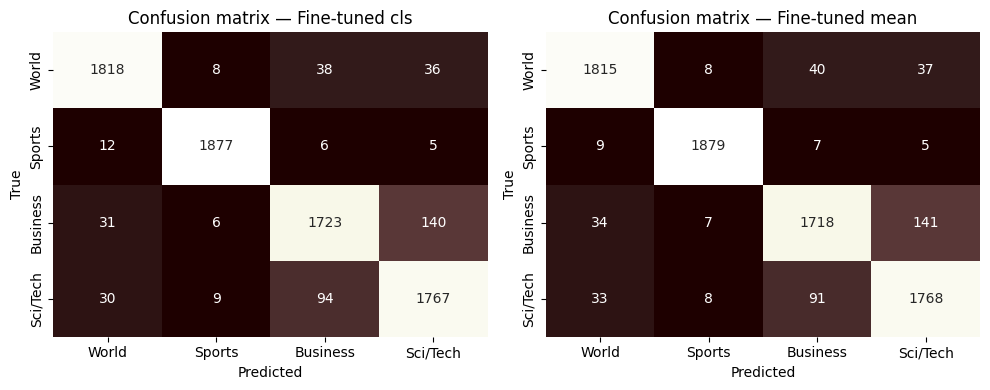

Fine-tuning cls-пулинг + голова
              precision    recall  f1-score   support

       World     0.9614    0.9568    0.9591      1900
      Sports     0.9879    0.9879    0.9879      1900
    Business     0.9258    0.9068    0.9162      1900
    Sci/Tech     0.9071    0.9300    0.9184      1900

    accuracy                         0.9454      7600
   macro avg     0.9456    0.9454    0.9454      7600
weighted avg     0.9456    0.9454    0.9454      7600


Fine-tuning mean-пулинг + голова
              precision    recall  f1-score   support

       World     0.9598    0.9553    0.9575      1900
      Sports     0.9879    0.9889    0.9884      1900
    Business     0.9256    0.9042    0.9148      1900
    Sci/Tech     0.9062    0.9305    0.9182      1900

    accuracy                         0.9447      7600
   macro avg     0.9449    0.9447    0.9447      7600
weighted avg     0.9449    0.9447    0.9447      7600



In [104]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_ft_cls, y_pred_ft_mean],
    ["Fine-tuned cls", "Fine-tuned mean"],
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="pink",
                xticklabels=["World", "Sports", "Business", "Sci/Tech"],
                yticklabels=["World", "Sports", "Business", "Sci/Tech"],
                cbar=False, ax=ax)
    ax.set_title(f"Confusion matrix — {title}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

print("Fine-tuning cls-пулинг + голова")
print(classification_report(y_test, y_pred_ft_cls,
                            target_names=["World", "Sports", "Business", "Sci/Tech"],
                            digits=4))

print("\nFine-tuning mean-пулинг + голова")
print(classification_report(y_test, y_pred_ft_mean,
                            target_names=["World", "Sports", "Business", "Sci/Tech"],
                            digits=4))

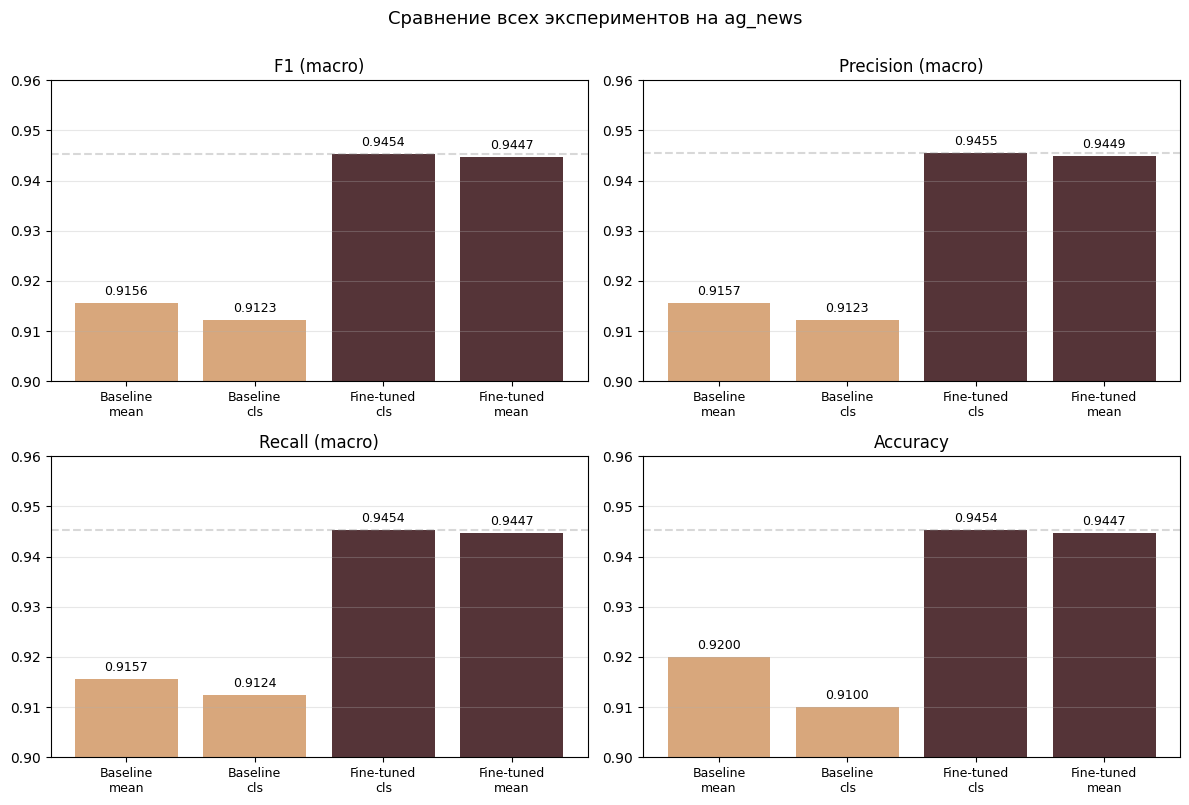

In [ ]:
labels = ["Baseline\nmean", "Baseline\ncls", "Fine-tuned\ncls", "Fine-tuned\nmean"]

metrics = {
    "F1 (macro)":        [0.9156, 0.9123, 0.9454, 0.9447],
    "Precision (macro)": [0.9157, 0.9123, 0.9455, 0.9449],
    "Recall (macro)":    [0.9157, 0.9124, 0.9454, 0.9447],
    "Accuracy":          [0.9200, 0.9100, 0.9454, 0.9447],
}

colors = ["#C57A39A8", "#C57A39A8", "#350E13D7", "#350E13D7"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (title, values) in zip(axes, metrics.items()):
    bars = ax.bar(labels, values, color=colors)
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width()/2, v + 0.001,
                f"{v:.4f}", ha="center", va="bottom", fontsize=9)

    ax.set_title(title)
    ax.set_ylim(0.9, 0.96)
    ax.axhline(y=max(values), color="gray", linestyle="--", alpha=0.3)
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", labelsize=9)

plt.suptitle("Сравнение всех экспериментов на ag_news", fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

## Вывод

В работе были проведены четыре эксперимента на датасете **ag_news** (4 сбалансированных класса, 120000 / 7600 примеров).  
В качестве модели векторизации была взята **DistilBERT**.

| № | Эксперимент | Энкодер | Пулинг | Классификатор | F1 (macro) | Precision (macro) | Recall (macro) | Accuracy |
|---|---|---|---|---|---|---|---|---|
| 1 | Baseline | заморожен | mean | LogisticRegression | 0.9156 | 0.9157 | 0.9157 | 0.9200 |
| 2 | Baseline | заморожен | cls | LogisticRegression | 0.9123 | 0.9123 | 0.9124 | 0.9100 |
| 3 | Fine-tuned 1 | дообучался | cls | классификационная голова | **0.9454** | **0.9455** | **0.9454** | **0.9454** |
| 4 | Fine-tuned 2 | дообучался | mean | классификационная голова | 0.9447 | 0.9449 | 0.9447 | 0.9447 |

Fine-tuning дал прирост F1 на **0.033** для cls-пулинга и на **0.029** для mean-пулинга. Дообучение адаптирует веса самого энкодера под тексты новостей из `ag_news`, а baseline использует замороженные веса.

В baseline mean pooling был на 0.003 лучше cls. После fine-tuning разница в использовании разных пулингов стала незначимой. Fine-tuning адаптирует все представления энкодера под задачу.

1. **Sports** распознаётся почти идеально;
2. **Business** путается с **World** (экономика разных стран) и **Sci/Tech** (технологические компании).